In [70]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

df = pd.read_csv("../Data/GoogleAds_DataAnalytics_Sales_Cleaned.csv")
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,231.88,14.0,7.0,0.058000,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,216.84,10.0,8.0,0.046000,1679.0,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,203.66,26.0,9.0,0.048979,1624.0,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,237.66,17.0,6.0,0.048979,1225.0,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,195.90,30.0,8.0,0.048979,1091.0,2024-11-22,hyderabad,desktop,online data analytic


In [71]:
df.shape

(2600, 13)

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   str    
 1   Campaign_Name    2600 non-null   str    
 2   Clicks           2600 non-null   float64
 3   Impressions      2600 non-null   float64
 4   Cost             2600 non-null   float64
 5   Leads            2600 non-null   float64
 6   Conversions      2600 non-null   float64
 7   Conversion Rate  2600 non-null   float64
 8   Sale_Amount      2600 non-null   float64
 9   Ad_Date          2600 non-null   str    
 10  Location         2600 non-null   str    
 11  Device           2600 non-null   str    
 12  Keyword          2600 non-null   str    
dtypes: float64(7), str(6)
memory usage: 264.2 KB


In [73]:
df["Ad_Date"] = (
    df["Ad_Date"]
    .astype("datetime64[ns]")
)

df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,231.88,14.0,7.0,0.058000,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,216.84,10.0,8.0,0.046000,1679.0,2024-11-20,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,203.66,26.0,9.0,0.048979,1624.0,2024-11-16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,237.66,17.0,6.0,0.048979,1225.0,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,195.90,30.0,8.0,0.048979,1091.0,2024-11-22,hyderabad,desktop,online data analytic


In [74]:
df.describe()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600
mean,138.956994,4523.280833,215.090623,20.077692,6.532692,0.048979,1498.648111,2024-10-30 10:22:31.384615168
min,80.000000,3000.000000,180.010000,10.000000,3.000000,0.015000,1000.000000,2024-01-11 00:00:00
25%,111.000000,3778.000000,198.385000,15.000000,5.000000,0.038000,1262.000000,2024-11-07 18:00:00
50%,138.956994,4523.280833,215.090623,20.000000,7.000000,0.048979,1498.648111,2024-11-16 00:00:00
75%,167.000000,5268.250000,232.297500,25.000000,8.000000,0.054000,1728.000000,2024-11-23 00:00:00
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.123000,2000.000000,2024-12-11 00:00:00
std,33.865226,860.843133,19.907373,6.000523,2.241415,0.017415,279.323553,NaN


In [75]:
df["Ad_Date"].isnull().sum()

np.int64(0)

In [76]:
df["Ad_Date"].isna().sum()

np.int64(0)

In [77]:
df["Campaign_Name"].value_counts()

Campaign_Name
Data Analytcis Course    680
Data Analytics Corse     647
DataAnalyticsCourse      637
Data Anlytics Corse      636
Name: count, dtype: int64

In [78]:
df["Location"].value_counts().head(10)

Location
HYDERABAD    661
Hyderbad     656
hyderabad    650
hydrebad     633
Name: count, dtype: int64

In [79]:
df["Location"].unique()

<StringArray>
['hyderabad', 'HYDERABAD', 'Hyderbad', 'hydrebad']
Length: 4, dtype: str

In [80]:
city_mapping = {
    'hyderbad': 'hyderabad',
    'hydrebad': 'hyderabad'
}
campaign_mapping = {
    'data analytics corse': 'data analytics course',
    'dataanalyticscourse': 'data analytics course',
    'data anlytics corse': 'data analytics course',
    'data analytcis course': 'data analytics course'
}
def clean_category(series, mapping):
    return (
        series
        .str.strip()
        .str.lower()
        .replace(mapping)
    )

df['Location'] = clean_category(df['Location'], city_mapping)
df['Campaign_Name'] = clean_category(df['Campaign_Name'], campaign_mapping)

In [81]:
df["Location"].unique()

<StringArray>
['hyderabad']
Length: 1, dtype: str

In [82]:
df["Campaign_Name"].unique()

<StringArray>
['data analytics course']
Length: 1, dtype: str

In [83]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058000,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046000,1679.0,2024-11-20,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,0.048979,1624.0,2024-11-16,hyderabad,Desktop,data analitics online
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,0.048979,1225.0,2024-11-26,hyderabad,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,0.048979,1091.0,2024-11-22,hyderabad,desktop,online data analytic


In [84]:
df["Device"].unique()

<StringArray>
['desktop',  'mobile', 'Desktop',  'tablet',  'MOBILE',  'TABLET',  'Tablet',
  'Mobile', 'DESKTOP']
Length: 9, dtype: str

In [85]:
device_act = {
    'desktop': 'Desktop',
    'DESKTOP': 'Desktop',
    'mobile': 'Mobile',
    'MOBILE': 'Mobile',
    'tablet': 'Tablet',
    'TABLET': 'Tablet'
}
def clean_category(series, mapping):
    return (
        series
        .str.strip()
        .str.lower()
        .replace(mapping)
    )

df['Device'] = clean_category(df['Device'], device_act)

In [86]:
df["Device"].unique()

<StringArray>
['Desktop', 'Mobile', 'Tablet']
Length: 3, dtype: str

In [87]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058000,1892.0,2024-11-16,hyderabad,Desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046000,1679.0,2024-11-20,hyderabad,Mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,0.048979,1624.0,2024-11-16,hyderabad,Desktop,data analitics online
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,0.048979,1225.0,2024-11-26,hyderabad,Tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,0.048979,1091.0,2024-11-22,hyderabad,Desktop,online data analytic


In [88]:
df.isnull().sum()

Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64

In [89]:
df.groupby('Campaign_Name')['Clicks'].sum().sort_values(ascending=False).head(10)

Campaign_Name
data analytics course    361288.18328
Name: Clicks, dtype: float64

In [90]:
df.groupby('Device')['Clicks'].mean().sort_values(ascending=False).head(10)

Device
Mobile     140.166900
Tablet     139.491942
Desktop    137.258295
Name: Clicks, dtype: float64

In [91]:
df.groupby('Ad_Date')['Sale_Amount'].mean().sort_values(ascending=False).head(10)

Ad_Date
2024-02-11    1609.224011
2024-01-11    1583.307267
2024-06-11    1573.395253
2024-11-04    1568.584144
2024-11-16    1557.847641
2024-11-07    1547.086894
2024-11-23    1541.775741
2024-11-29    1540.180772
2024-11-28    1537.635641
2024-09-11    1530.574914
Name: Sale_Amount, dtype: float64

In [92]:
daily_sales = df.groupby("Ad_Date")["Sale_Amount"].sum()

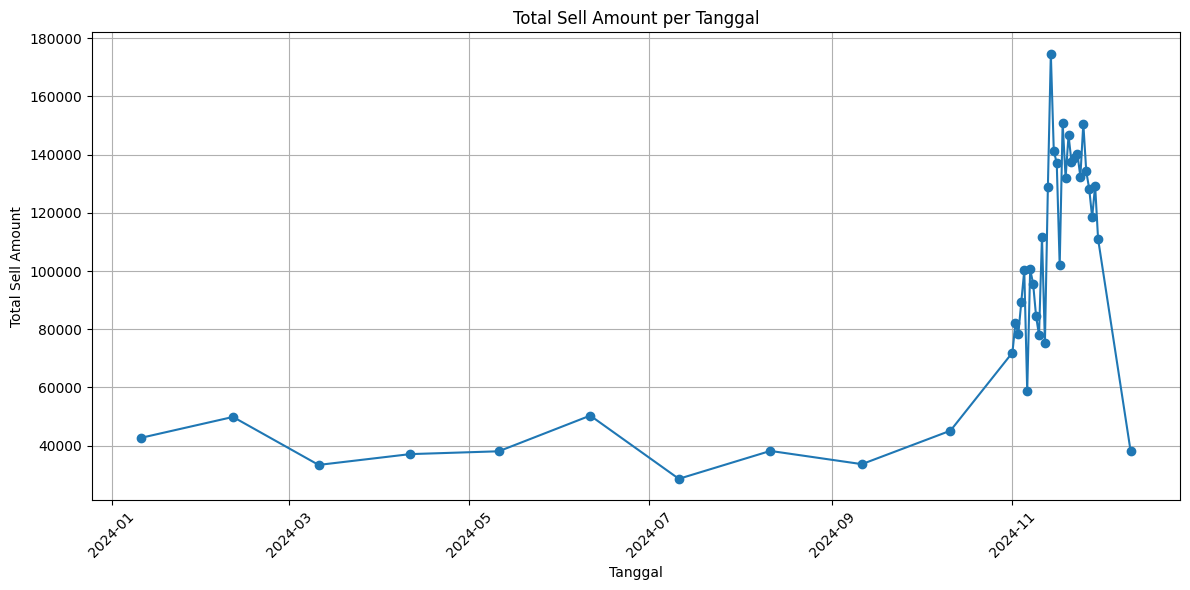

In [93]:
plt.figure(figsize=(12, 6))

plt.plot(daily_sales.index, daily_sales.values, marker="o")

plt.title("Total Sell Amount per Tanggal")
plt.xlabel("Tanggal")
plt.ylabel("Total Sell Amount")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

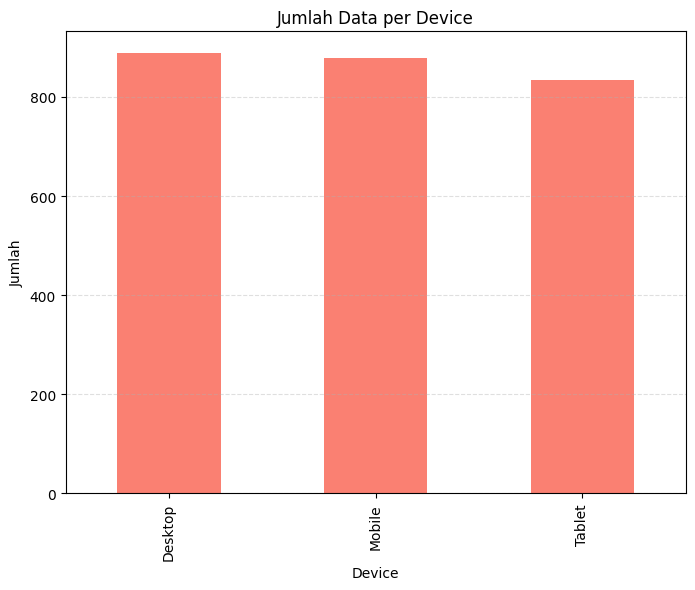

In [94]:
device_count = df["Device"].value_counts()

plt.figure(figsize=(8, 6))
device_count.plot(kind="bar", color="salmon")

plt.title("Jumlah Data per Device")
plt.xlabel("Device")
plt.ylabel("Jumlah")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

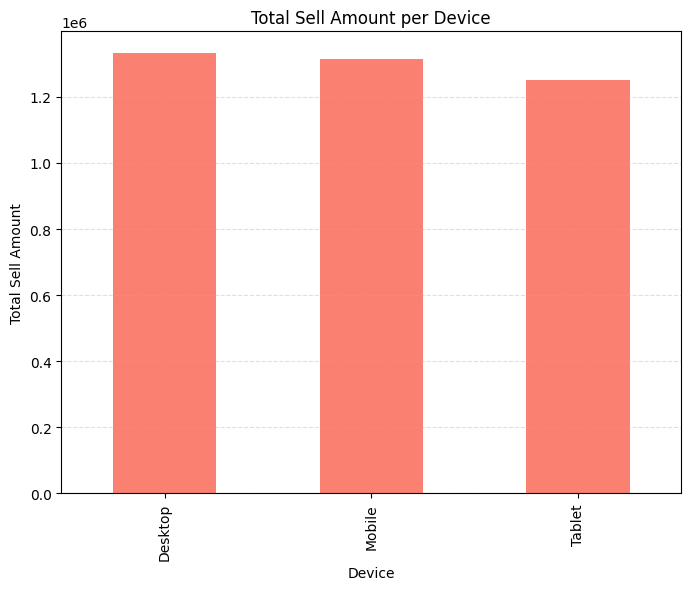

In [95]:
device_sales = df.groupby("Device")["Sale_Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
device_sales.plot(kind="bar", color="salmon")

plt.title("Total Sell Amount per Device")
plt.xlabel("Device")
plt.ylabel("Total Sell Amount")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()